# School Abandonment

In [3]:
import pandas as pd
import matplotlib.pylab as plt

data = pd.read_csv('educ_uoe_enra27_linear.csv')
data.sample()

,DATAFLOW,LAST UPDATE,freq,age,sex,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
1242,ESTAT:EDUC_UOE_ENRA27(1.0),11/09/25 23:00:00,Annual,15 years,Females,Percentage,Malta,2021,0.49,NaN,NaN


In [4]:
# let's only take the values that we care about, and also add a mean for all ages

romania = data[data.geo == 'Romania'][['age', 'sex', 'TIME_PERIOD', 'OBS_VALUE']]
mean_all_ages = (
    romania.groupby(['TIME_PERIOD', 'sex'], as_index=False)['OBS_VALUE']
    .mean()
    .assign(age='All ages')
)
romania = pd.concat([romania, mean_all_ages], ignore_index=True)
romania.sample()

,age,sex,TIME_PERIOD,OBS_VALUE
7,14 years,Females,2022,15.07


Text(0.5, 1.0, 'School abandonment rate (Romania, all ages)')

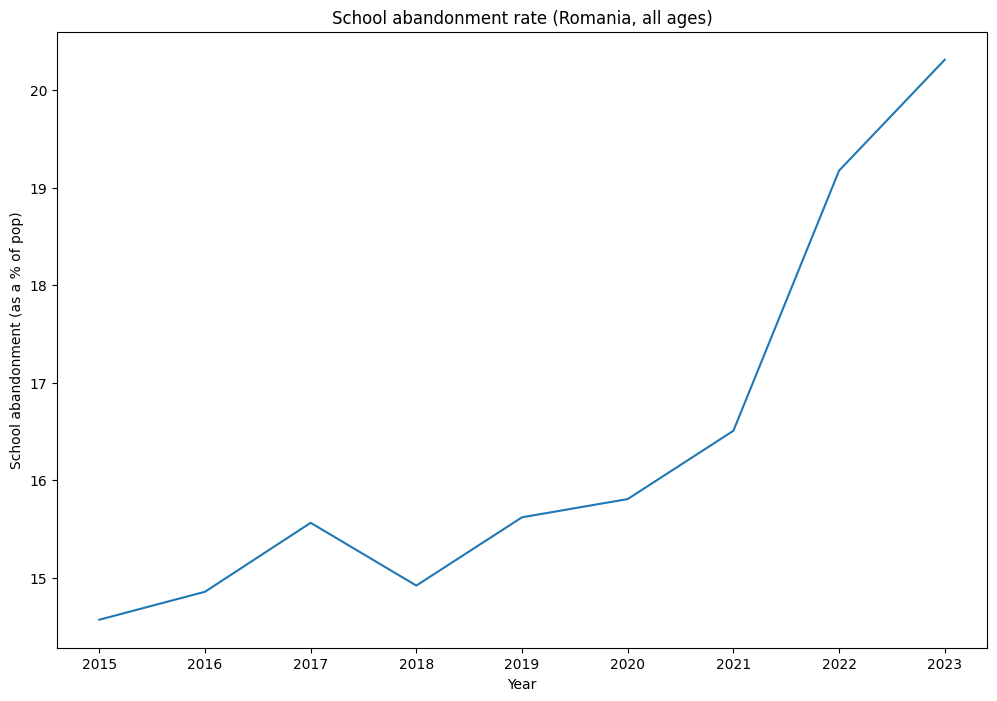

In [5]:
all_ages_sexes = romania[(romania.age == 'All ages') & (romania.sex == 'Total')]

plt.figure(figsize=(12, 8))
plt.plot(all_ages_sexes.TIME_PERIOD, all_ages_sexes.OBS_VALUE)
plt.xticks(all_ages_sexes.TIME_PERIOD)
plt.xlabel("Year")
plt.ylabel("School abandonment (as a % of pop)")
plt.title("School abandonment rate (Romania, all ages)")

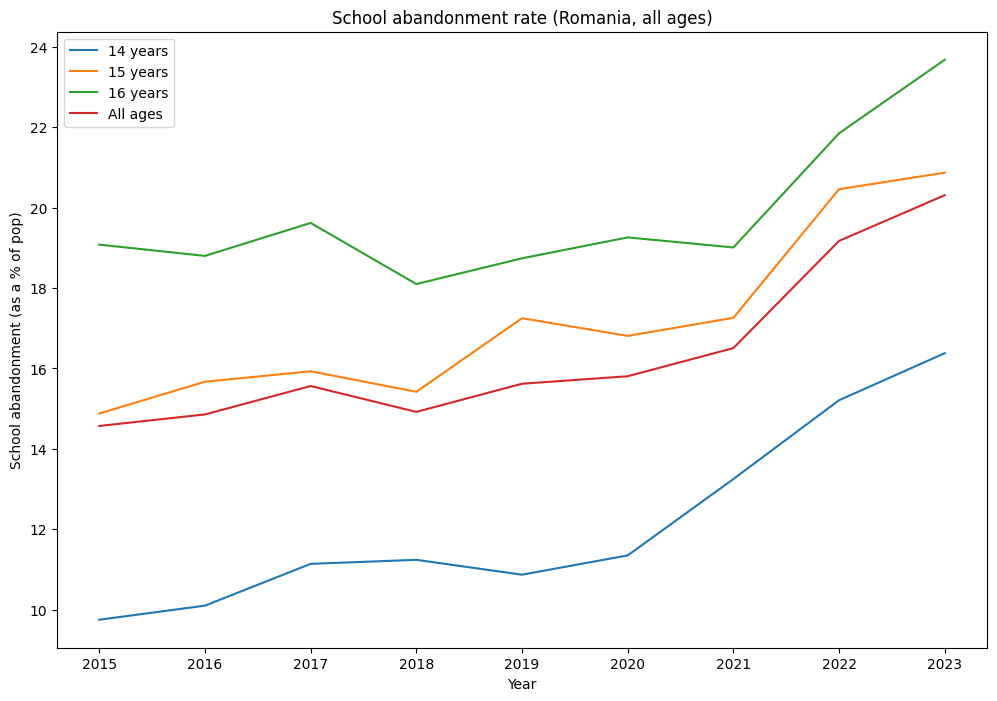

In [6]:
# let's compare all the ages

from functools import cmp_to_key
def compare_func(a, b):
    if a[0:2].isdigit() and b[0:2].isdigit():
        return int(a[0:2]) - int(b[0:2])
    elif a[0:2].isdigit():
        return -1
    elif b[0:2].isdigit():
        return 1
    return 0

age_groups = sorted(set(romania.age), key=cmp_to_key(compare_func))
plt.figure(figsize=(12, 8))

for age_group in age_groups:
    specific_age = romania[(romania.age == age_group) & (romania.sex == 'Total')]
    plt.plot(specific_age.TIME_PERIOD, specific_age.OBS_VALUE, label=age_group)


plt.xticks(all_ages_sexes.TIME_PERIOD)
plt.xlabel("Year")
plt.ylabel("School abandonment (as a % of pop)")
plt.title("School abandonment rate (Romania, all ages)")
plt.legend()

In [30]:
# ok let's look at all countries in the EU

data2023_16y = data[(data.TIME_PERIOD == 2023) & (data.sex == 'Total') & (data.age == '16 years')] [['geo', 'OBS_VALUE']]
data2023_16y.sort_values(by='OBS_VALUE', inplace=True)
data2023_16y.dropna(inplace=True)
data2023_16y.drop(data2023_16y[data2023_16y.OBS_VALUE == 0].index, inplace=True)
data2023_16y.head(5)

,geo,OBS_VALUE
2727,Cyprus,0.58
2982,Sweden,1.02
2928,Netherlands,1.22
2700,Belgium,1.42
2991,Slovenia,2.47


Text(0.5, 1.0, 'School abandonment rate (2023) by country')

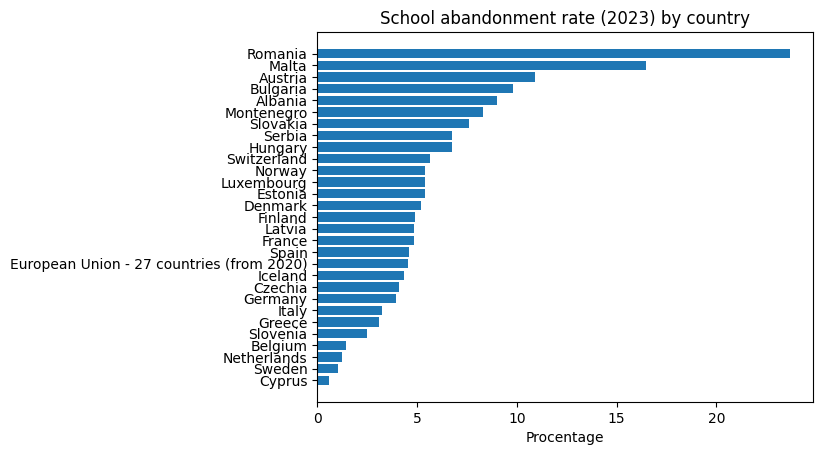

In [31]:
plt.barh(data2023_16y.geo, data2023_16y.OBS_VALUE)

plt.xlabel("Procentage")
plt.title("School abandonment rate (2023) by country")